In [2]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.feature import COASTLINE, BORDERS
import colormaps
from daltonize.daltonize import daltonize, daltonize_mpl
from matplotlib.colors import Normalize, BoundaryNorm
from matplotlib.ticker import AutoLocator, MaxNLocator
from matplotlib.cm import ScalarMappable
savedir = Path("/Users/bandelol/Documents/code_local/local_figs/nice_colorbars")
mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.titlesize"] = 11
mpl.rcParams["axes.labelsize"] = 11
mpl.rcParams["axes.titlepad"] = 2
mpl.rcParams["xtick.labelsize"] = 11
mpl.rcParams["ytick.labelsize"] = 11
mpl.rcParams["legend.fontsize"] = 11
mpl.rcParams["figure.titlesize"] = 11
mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["savefig.bbox"] = "tight"
mpl.rcParams["text.usetex"] = False
mpl.rcParams["animation.ffmpeg_path"] = r"~/mambaforge/envs/env11/bin/ffmpeg"

In [3]:
sample = xr.open_dataset("/Users/bandelol/Documents/code_local/data/flat_wind_sample.nc")
sample = sample.sel(lon=slice(-80, 40), lat=slice(10, 80))
lon, lat = sample.lon.values, sample.lat.values

# Basics

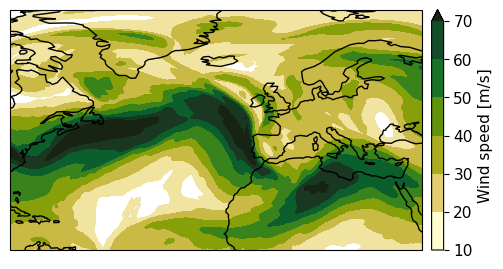

In [63]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
cmap = colormaps.speed
to_plot = sample["s"][0]
levels = MaxNLocator(6).tick_values(to_plot.quantile(0.05), to_plot.quantile(0.95))
norm = BoundaryNorm(levels, cmap.N, extend="max")
ax.contourf(lon, lat, to_plot, cmap=cmap, levels=levels, extend="max")
fig.colorbar(ScalarMappable(norm, cmap), ax=ax, shrink=0.65, pad=0.02, label="Wind speed [m/s]")
ax.add_feature(COASTLINE)
fig.savefig(savedir.joinpath("good.png"))

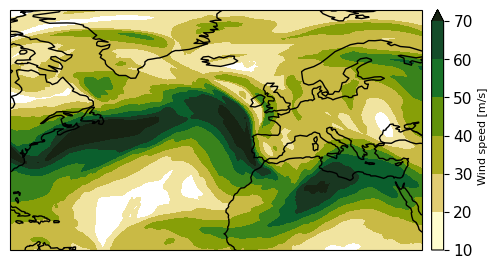

In [28]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
cmap = colormaps.speed
to_plot = sample["s"][0]
levels = MaxNLocator(6).tick_values(to_plot.quantile(0.05), to_plot.quantile(0.95))
norm = BoundaryNorm(levels, cmap.N, extend="max")
ax.contourf(lon, lat, to_plot, cmap=cmap, levels=levels, extend="max")
cbar = fig.colorbar(ScalarMappable(norm, cmap), ax=ax, shrink=0.65, pad=0.02)
cbar.ax.set_ylabel("Wind speed [m/s]", fontsize=8)
ax.add_feature(COASTLINE)
fig.savefig(savedir.joinpath("too_small.png"))

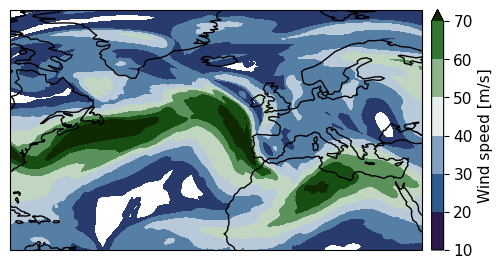

In [30]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
cmap = colormaps.cork
to_plot = sample["s"][0]
levels = MaxNLocator(6).tick_values(to_plot.quantile(0.05), to_plot.quantile(0.95))
norm = BoundaryNorm(levels, cmap.N, extend="max")
ax.contourf(lon, lat, to_plot, cmap=cmap, levels=levels, extend="max")
fig.colorbar(ScalarMappable(norm, cmap), ax=ax, shrink=0.65, pad=0.02, label="Wind speed [m/s]")
ax.add_feature(COASTLINE)
fig.savefig(savedir.joinpath("symmetric_wrong.png"))

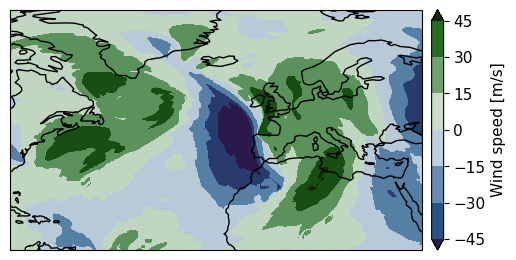

In [31]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
cmap = colormaps.cork
to_plot = sample["v"][0]
levels = MaxNLocator(6, symmetric=True).tick_values(to_plot.quantile(0.05), to_plot.quantile(0.95))
norm = BoundaryNorm(levels, cmap.N, extend="both")
ax.contourf(lon, lat, to_plot, cmap=cmap, levels=levels, extend="both")
fig.colorbar(ScalarMappable(norm, cmap), ax=ax, shrink=0.65, pad=0.02, label="Wind speed [m/s]")
ax.add_feature(COASTLINE)
fig.savefig(savedir.joinpath("symmetric_good.png"))

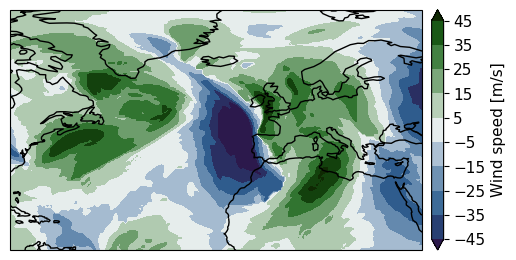

In [32]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
cmap = colormaps.cork
to_plot = sample["v"][0]
levels = np.arange(-45, 55, 10)
norm = BoundaryNorm(levels, cmap.N, extend="both")
ax.contourf(lon, lat, to_plot, cmap=cmap, levels=levels, extend="both")
fig.colorbar(ScalarMappable(norm, cmap), ax=ax, shrink=0.65, pad=0.02, label="Wind speed [m/s]")
ax.add_feature(COASTLINE)
fig.savefig(savedir.joinpath("symmetric_good_2.png"))

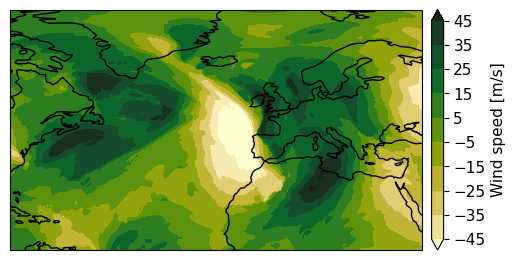

In [33]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
cmap = colormaps.speed
to_plot = sample["v"][0]
levels = np.arange(-45, 55, 10)
norm = BoundaryNorm(levels, cmap.N, extend="both")
ax.contourf(lon, lat, to_plot, cmap=cmap, levels=levels, extend="both")
fig.colorbar(ScalarMappable(norm, cmap), ax=ax, shrink=0.65, pad=0.02, label="Wind speed [m/s]")
ax.add_feature(COASTLINE)
fig.savefig(savedir.joinpath("nonsymmetric_bad.png"))

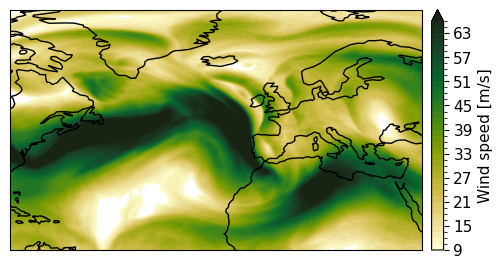

In [34]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
cmap = colormaps.speed
to_plot = sample["s"][0]
levels = MaxNLocator(50).tick_values(to_plot.quantile(0.05), to_plot.quantile(0.95))
norm = BoundaryNorm(levels, cmap.N, extend="max")
ax.contourf(lon, lat, to_plot, cmap=cmap, levels=levels, extend="max")
fig.colorbar(ScalarMappable(norm, cmap), ax=ax, shrink=0.65, pad=0.02, label="Wind speed [m/s]")
ax.add_feature(COASTLINE)
fig.savefig(savedir.joinpath("too_many_levels.png"))

# Colorblind friendliness

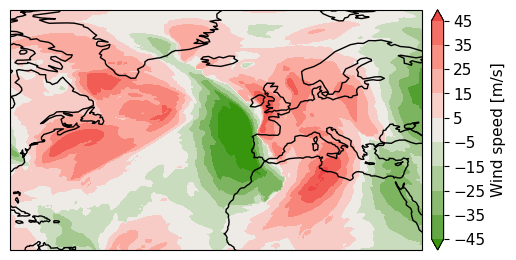

In [21]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
cmap = colormaps.cet_d_gwr
to_plot = sample["v"][0]
levels = np.arange(-45, 55, 10)
norm = BoundaryNorm(levels, cmap.N, extend="both")
ax.contourf(lon, lat, to_plot, cmap=cmap, levels=levels, extend="both")
fig.colorbar(ScalarMappable(norm, cmap), ax=ax, shrink=0.65, pad=0.02, label="Wind speed [m/s]")
ax.add_feature(COASTLINE)
fig.savefig(savedir.joinpath("colorblind_base.png"))

/Users/bandelol/mambaforge/envs/env2/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


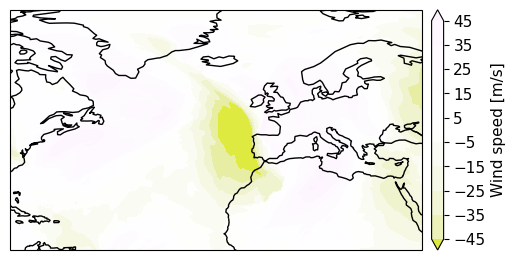

In [22]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
cmap = colormaps.cet_d_gwr
to_plot = sample["v"][0]
levels = np.arange(-45, 55, 10)
norm = BoundaryNorm(levels, cmap.N, extend="both")
ax.contourf(lon, lat, to_plot, cmap=cmap, levels=levels, extend="both")
fig.colorbar(ScalarMappable(norm, cmap), ax=ax, shrink=0.65, pad=0.02, label="Wind speed [m/s]")
ax.add_feature(COASTLINE)
for deficit in ["d", "p", "t"]:
    fig2 = daltonize_mpl(fig, color_deficit=deficit)
    fig2.savefig(savedir.joinpath(f"colorblind_{deficit}.png"))

# Standard color choices

# Multiple plots

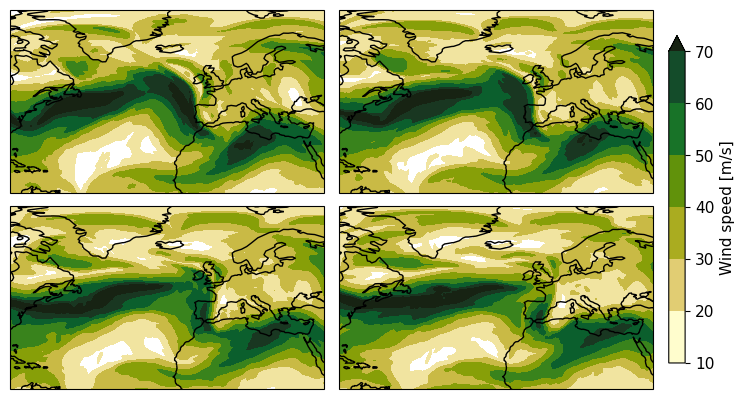

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5), subplot_kw={"projection": ccrs.PlateCarree()}, gridspec_kw=dict(wspace=0.05, hspace=.04))
axes = axes.ravel()
cmap = colormaps.speed
to_plot = sample["s"][:4]
levels = MaxNLocator(6).tick_values(to_plot.quantile(0.05), to_plot.quantile(0.95))
norm = BoundaryNorm(levels, cmap.N, extend="max")
for ax, tplt in zip(axes, to_plot):
    ax.contourf(lon, lat, tplt, cmap=cmap, levels=levels, extend="max")
    ax.add_feature(COASTLINE)
fig.colorbar(ScalarMappable(norm, cmap), ax=axes, shrink=0.85, pad=0.02, label="Wind speed [m/s]")
fig.savefig(savedir.joinpath("good_multiple.png"))

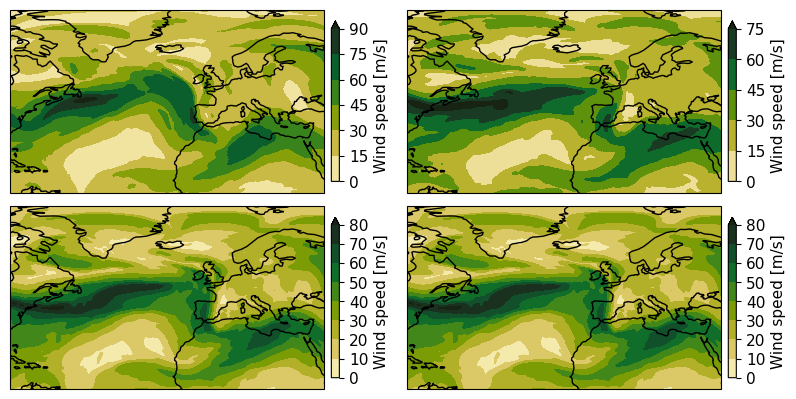

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5), subplot_kw={"projection": ccrs.PlateCarree()}, gridspec_kw=dict(wspace=0.05, hspace=.04))
axes = axes.ravel()
cmap = colormaps.speed
to_plot = sample["s"][np.random.choice(len(to_plot), 4)]
for ax, tplt in zip(axes, to_plot):
    im = ax.contourf(lon, lat, tplt, cmap=cmap, levels=7, extend="max")
    ax.add_feature(COASTLINE)
    fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02, label="Wind speed [m/s]")
fig.savefig(savedir.joinpath("bad_multiple.png"))